In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv("D:\SSAFY\GamjaNeverDie\merged_df.csv", encoding = "utf-8")

In [3]:
print(f"전체 데이터 shape: {df.shape}")
print(f"\n컬럼 목록:\n{df.columns.tolist()}")
print(f"\n가맹점 수: {df['가맹점구분번호'].nunique()}")
print(f"기간: {df['기준년월'].min()} ~ {df['기준년월'].max()}")

전체 데이터 shape: (1960290, 39)

컬럼 목록:
['가맹점구분번호', '가맹점주소', '가맹점명', '브랜드구분코드', '가맹점지역', '업종', '상권', '개설일', '폐업일', '기준년월', '가맹점 운영개월수 구간', '매출금액 구간', '매출건수 구간', '유니크 고객 수 구간', '객단가 구간', '취소율 구간', '배달매출금액 비율', '동일 업종 매출금액 비율', '동일 업종 매출건수 비율', '동일 업종 내 매출 순위 비율', '동일 상권 내 매출 순위 비율', '동일 업종 내 해지 가맹점 비중', '동일 상권 내 해지 가맹점 비중', '기준년월.1', '남성 20대이하 고객 비중', '남성 30대 고객 비중', '남성 40대 고객 비중', '남성 50대 고객 비중', '남성 60대이상 고객 비중', '여성 20대이하 고객 비중', '여성 30대 고객 비중', '여성 40대 고객 비중', '여성 50대 고객 비중', '여성 60대이상 고객 비중', '재방문 고객 비중', '신규 고객 비중', '거주 이용 고객 비율', '직장 이용 고객 비율', '유동인구 이용 고객 비율']

가맹점 수: 4185
기간: 202301 ~ 202412


In [4]:
special_values = [-999999.9, 999999.9]
for col in df.select_dtypes(include=[np.number]).columns:
    df.loc[df[col].isin(special_values), col] = np.nan

# 날짜 형식 변환
df['기준년월'] = pd.to_datetime(df['기준년월'], format='%Y%m', errors='coerce')
df['개설일'] = pd.to_datetime(df['개설일'], format='%Y%m%d', errors='coerce')
df['폐업일'] = pd.to_datetime(df['폐업일'], format='%Y%m%d', errors='coerce')

# 개설일 ~ 기준년월 기간 필터링
df = df[df['기준년월'] >= df['개설일']].copy()
df = df[(df['폐업일'].isna()) | (df['기준년월'] <= df['폐업일'])].copy()

print(f"\n정제 후 데이터 shape: {df.shape}")


정제 후 데이터 shape: (1946312, 39)


In [5]:
# 3. 파생변수 생성
# ============================================================

# 구간값을 숫자로 변환하는 함수
def interval_to_numeric(interval_str):
    if pd.isna(interval_str):
        return np.nan
    mapping = {
        '10%이하': 5,
        '10-25%': 17.5,
        '25-50%': 37.5,
        '50-75%': 62.5,
        '75-90%': 82.5,
        '90%초과': 95
    }
    return mapping.get(str(interval_str), np.nan)

# 매출 관련 구간 변환
df['매출금액_수치'] = df['매출금액 구간'].apply(interval_to_numeric)
df['매출건수_수치'] = df['매출건수 구간'].apply(interval_to_numeric)
df['고객수_수치'] = df['유니크 고객 수 구간'].apply(interval_to_numeric)
df['객단가_수치'] = df['객단가 구간'].apply(interval_to_numeric)

# 취소율 구간 변환
df['취소율_수치'] = pd.to_numeric(df['취소율 구간'], errors='coerce')

# 가맹점별 시계열 정렬
df = df.sort_values(['가맹점구분번호', '기준년월']).reset_index(drop=True)

# 전월 대비 변화율 계산
for col_orig, col_new in [('매출금액_수치', '매출금액_변화율'), 
                          ('매출건수_수치', '매출건수_변화율'),
                          ('객단가_수치', '객단가_변화율')]:
    df[col_new] = df.groupby('가맹점구분번호')[col_orig].pct_change()

# 취소율 증감
df['취소율_증감'] = df.groupby('가맹점구분번호')['취소율_수치'].diff()

# 매출 표준편차
df['매출_표준편차_6개월'] = df.groupby('가맹점구분번호')['매출금액_수치'].transform(
    lambda x: x.rolling(window=6, min_periods=3).std()
)
df['매출_표준편차_3개월'] = df.groupby('가맹점구분번호')['매출금액_수치'].transform(
    lambda x: x.rolling(window=3, min_periods=2).std()
)

# 매출 안정성 지수
df['매출_평균_6개월'] = df.groupby('가맹점구분번호')['매출금액_수치'].transform(
    lambda x: x.rolling(window=6, min_periods=3).mean()
)
df['매출_안정성지수'] = df['매출_평균_6개월'] / (df['매출_표준편차_6개월'] + 1e-5)

# 고객 다양성 지수
gender_age_cols = [
    '남성 20대이하 고객 비중', '남성 30대 고객 비중', '남성 40대 고객 비중', 
    '남성 50대 고객 비중', '남성 60대이상 고객 비중',
    '여성 20대이하 고객 비중', '여성 30대 고객 비중', '여성 40대 고객 비중',
    '여성 50대 고객 비중', '여성 60대이상 고객 비중'
]

def calculate_diversity(row):
    try:
        values = []
        for col in gender_age_cols:
            val = row[col]
            if pd.notna(val) and isinstance(val, (int, float)):
                values.append(float(val))
        
        if len(values) == 0 or sum(values) == 0:
            return np.nan
        
        values = np.array(values)
        probs = values / values.sum()
        probs = probs[probs > 0]
        return -np.sum(probs * np.log(probs))
    except:
        return np.nan

df['고객_다양성지수'] = df.apply(calculate_diversity, axis=1)

print("\n파생변수 생성 완료")


파생변수 생성 완료


In [6]:
# 4. 목표 변수 정의 (수정)
# ============================================================

# 4-1. 취소율 급증 여부
# 취소율이 존재하는 데이터만 필터링
df_with_cancel = df[df['취소율_수치'].notna()].copy()

# 업종별 취소율 평균 계산
industry_cancel_mean = df_with_cancel.groupby(['업종', '기준년월'])['취소율_수치'].mean().reset_index()
industry_cancel_mean.columns = ['업종', '기준년월', '업종_평균취소율']

df = df.merge(industry_cancel_mean, on=['업종', '기준년월'], how='left')

# 취소율 급증: 업종 평균 대비 1.5배 이상
df['취소율_급증여부'] = 0
mask = (df['취소율_수치'].notna()) & (df['업종_평균취소율'].notna()) & \
       (df['취소율_수치'] >= df['업종_평균취소율'] * 1.5)
df.loc[mask, '취소율_급증여부'] = 1

# 4-2. 매출 변동성 급증 여부
# 매출 표준편차가 존재하는 데이터만 필터링
df_with_vol = df[df['매출_표준편차_3개월'].notna()].copy()
volatility_threshold = df_with_vol['매출_표준편차_3개월'].quantile(0.8)

df['매출변동성_급증여부'] = 0
df.loc[df['매출_표준편차_3개월'] >= volatility_threshold, '매출변동성_급증여부'] = 1

print(f"\n목표 변수 정의 완료:")
print(f"취소율_수치 결측치: {df['취소율_수치'].isna().sum()} / {len(df)}")
print(f"업종_평균취소율 결측치: {df['업종_평균취소율'].isna().sum()} / {len(df)}")
print(f"취소율 급증 비율: {df['취소율_급증여부'].sum()} / {len(df)} = {df['취소율_급증여부'].mean():.2%}")
print(f"매출 변동성 급증 비율: {df['매출변동성_급증여부'].sum()} / {len(df)} = {df['매출변동성_급증여부'].mean():.2%}")

# 취소율 분포 확인
print(f"\n취소율_수치 통계:")
print(df['취소율_수치'].describe())
print(f"\n업종_평균취소율 통계:")
print(df['업종_평균취소율'].describe())


목표 변수 정의 완료:
취소율_수치 결측치: 1946312 / 1946312
업종_평균취소율 결측치: 1946312 / 1946312
취소율 급증 비율: 0 / 1946312 = 0.00%
매출 변동성 급증 비율: 0 / 1946312 = 0.00%

취소율_수치 통계:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: 취소율_수치, dtype: float64

업종_평균취소율 통계:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: 업종_평균취소율, dtype: float64



상관관계 분석을 위한 충분한 데이터가 없습니다.


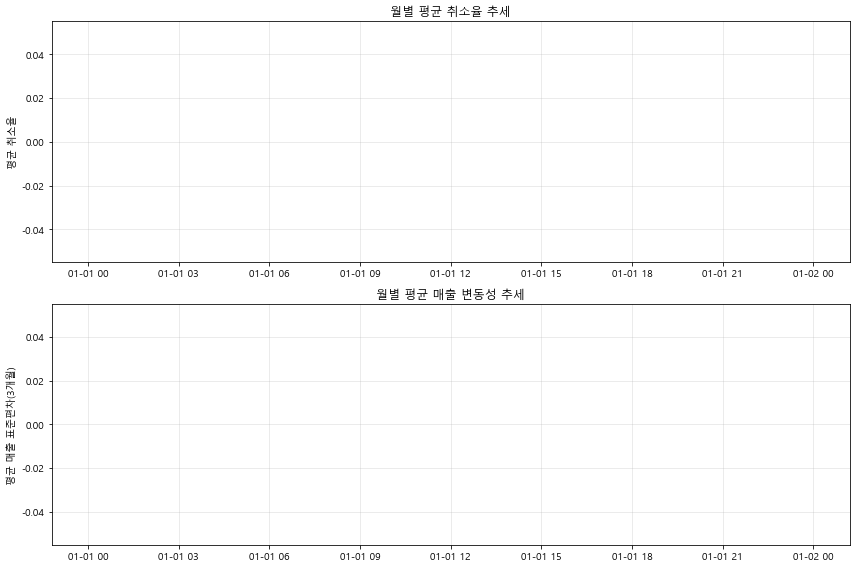

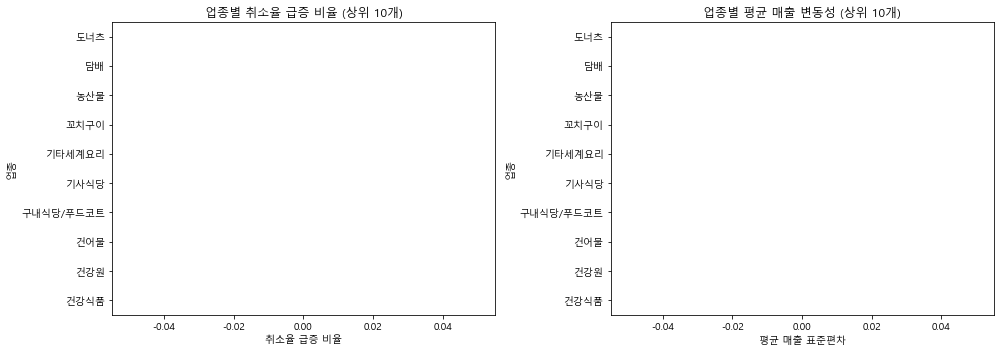


EDA 완료: 시각화 파일 저장됨


In [7]:
# 5. 탐색적 데이터 분석 (EDA)
# ============================================================

# 5-1. 상관관계 분석
correlation_features = [
    '매출금액_수치', '매출건수_수치', '객단가_수치',
    '취소율_수치', '배달매출금액 비율', '동일 업종 매출금액 비율',
    '재방문 고객 비중', '신규 고객 비중', 
    '매출_표준편차_3개월', '고객_다양성지수'
]

# 결측치가 있는 경우 처리
corr_df = df[correlation_features].dropna()

if len(corr_df) > 0:
    plt.figure(figsize=(14, 10))
    corr_matrix = corr_df.corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('주요 변수 간 상관관계')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\n상관관계 분석을 위한 충분한 데이터가 없습니다.")

# 5-2. 시계열 추세 분석
monthly_stats = df.groupby('기준년월').agg({
    '취소율_수치': 'mean',
    '취소율_급증여부': 'mean',
    '매출_표준편차_3개월': 'mean',
    '매출변동성_급증여부': 'mean'
}).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(monthly_stats['기준년월'], monthly_stats['취소율_수치'], marker='o')
axes[0].set_title('월별 평균 취소율 추세')
axes[0].set_ylabel('평균 취소율')
axes[0].grid(True, alpha=0.3)

axes[1].plot(monthly_stats['기준년월'], monthly_stats['매출_표준편차_3개월'], marker='s', color='orange')
axes[1].set_title('월별 평균 매출 변동성 추세')
axes[1].set_ylabel('평균 매출 표준편차(3개월)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('time_series_trends.png', dpi=300, bbox_inches='tight')
plt.show()

# 5-3. 업종별 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 업종별 취소율 급증 비율
industry_cancel = df.groupby('업종')['취소율_급증여부'].mean().sort_values(ascending=False).head(10)
if len(industry_cancel) > 0:
    industry_cancel.plot(kind='barh', ax=axes[0], color='coral')
    axes[0].set_title('업종별 취소율 급증 비율 (상위 10개)')
    axes[0].set_xlabel('취소율 급증 비율')

# 업종별 매출 변동성
industry_vol = df.groupby('업종')['매출_표준편차_3개월'].mean().sort_values(ascending=False).head(10)
if len(industry_vol) > 0:
    industry_vol.plot(kind='barh', ax=axes[1], color='skyblue')
    axes[1].set_title('업종별 평균 매출 변동성 (상위 10개)')
    axes[1].set_xlabel('평균 매출 표준편차')

plt.tight_layout()
plt.savefig('industry_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nEDA 완료: 시각화 파일 저장됨")